In [18]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

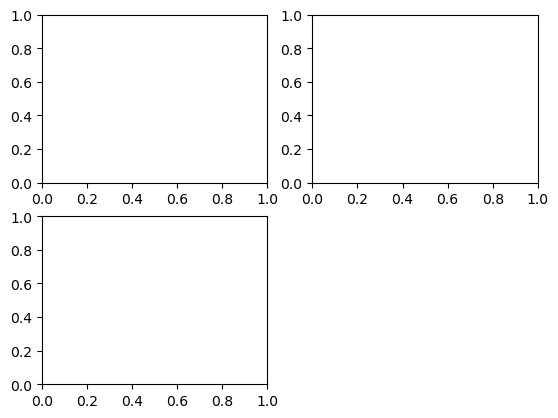

In [19]:
fig = plt.figure()
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)

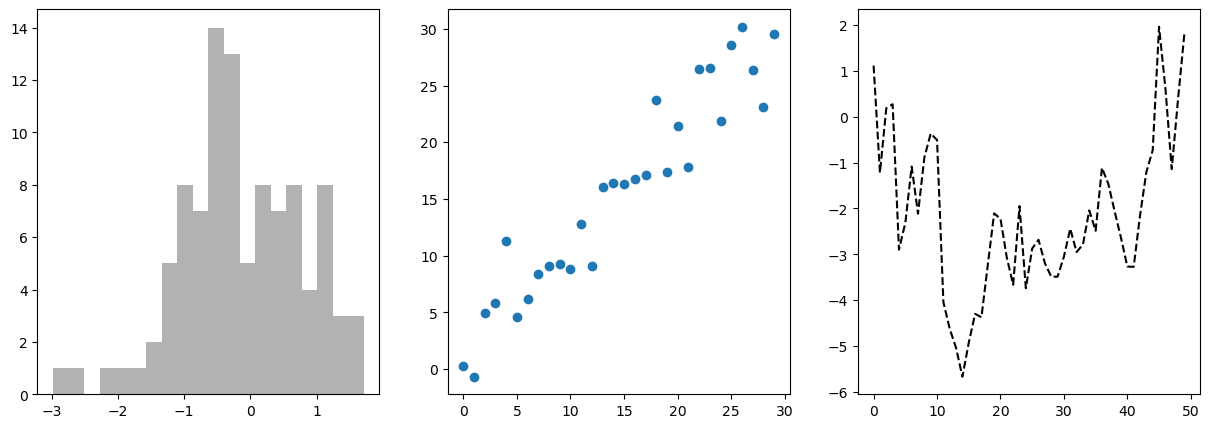

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure and a 1x3 grid of subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Now your plotting code will work perfectly!
ax1.hist(np.random.standard_normal(100), bins=20, color="black", alpha=0.3)
ax2.scatter(np.arange(30), np.arange(30) + 3 * np.random.standard_normal(30))
ax3.plot(np.random.standard_normal(50).cumsum(), color="black", linestyle="dashed")

plt.show()

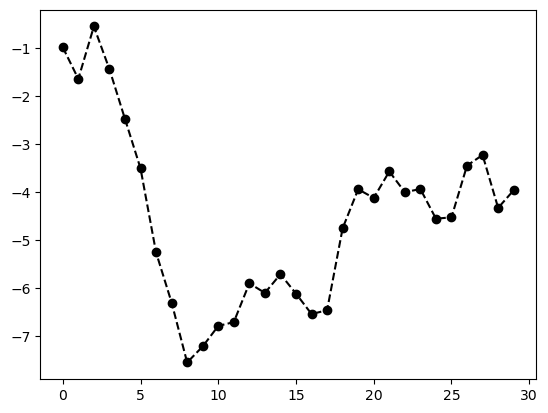

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Create the figure canvas first
fig = plt.figure()

# 2. Add the subplot to the figure
ax = fig.add_subplot()

# 3. Plot your data
ax.plot(np.random.standard_normal(30).cumsum(), color="black", linestyle="dashed", marker="o")

# 4. Display the plot
plt.show()

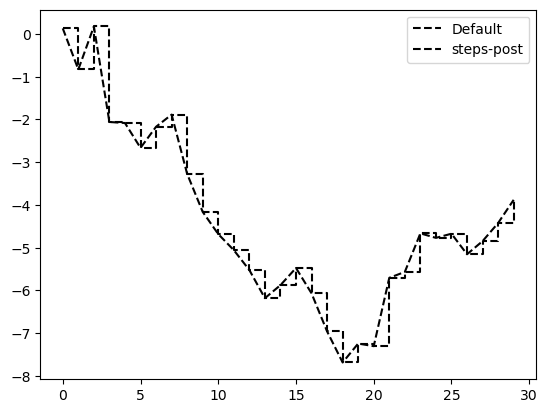

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Initialize the figure and axes
fig = plt.figure()
ax = fig.add_subplot()

# 2. Generate the random walk data
data = np.random.standard_normal(30).cumsum()

# 3. Plot the data with different draw styles
ax.plot(data, color="black", linestyle="dashed", label="Default")
ax.plot(data, color="black", linestyle="dashed", drawstyle="steps-post", label="steps-post")

# 4. Add the legend and suppress text output with a semicolon
ax.legend()

Generating dataset: 100 samples × 253 features

Data scaled successfully.

Running KMeans...
Running HDBSCAN...
KMeans  completed in 0.07s
HDBSCAN completed in 0.02s


=== KMeans Cluster Distribution ===
   Cluster  Count  Percentage
0        0     13        13.0
1        1      7         7.0
2        2      6         6.0
3        3     18        18.0
4        4     30        30.0
5        5     11        11.0
6        6      8         8.0
7        7      7         7.0
Total clusters (excluding noise): 8

=== HDBSCAN Cluster Distribution ===
   Cluster  Count  Percentage
0       -1    100       100.0
Total clusters (excluding noise): 0
Noise points: 100

Reducing dimensions to 3D for visualization...


d:\env\py128\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


PCA explained variance: 7.27%
Running UMAP...


d:\env\py128\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


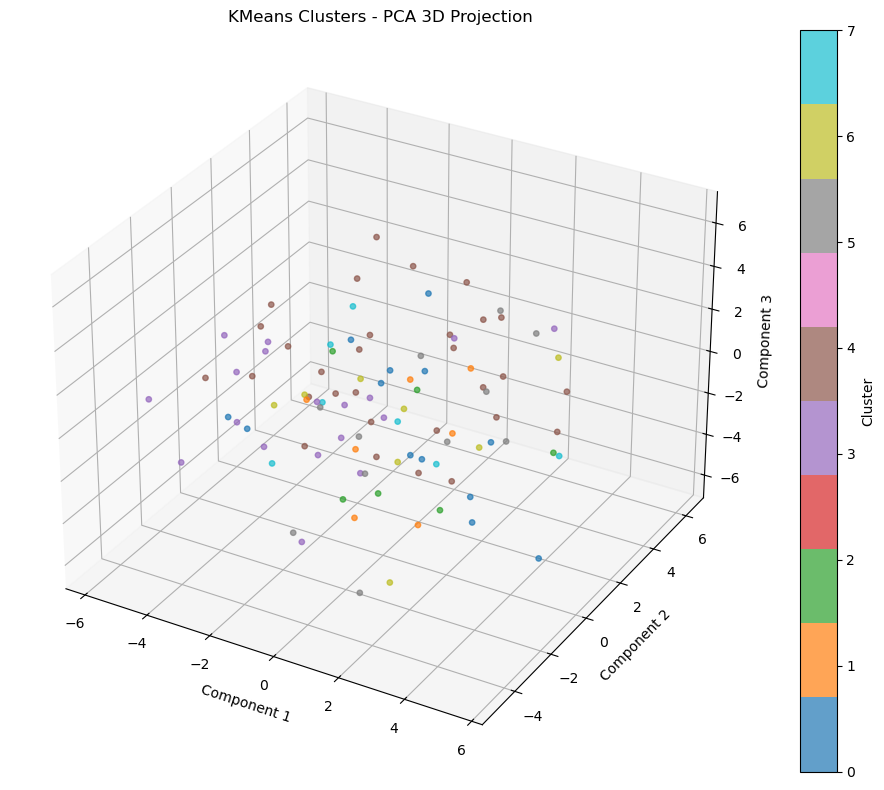

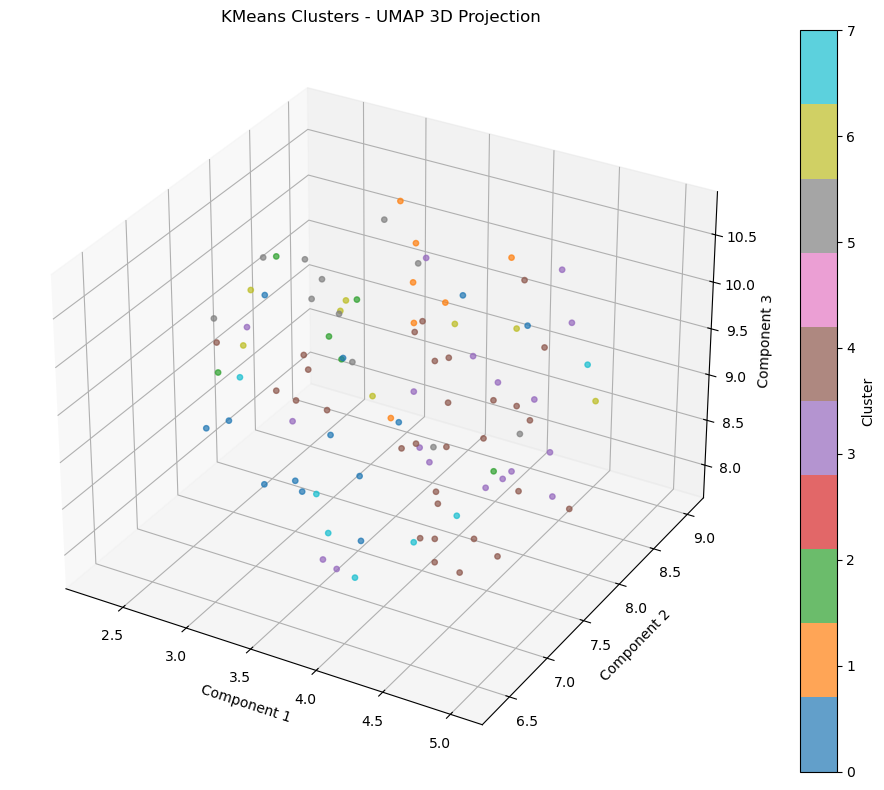

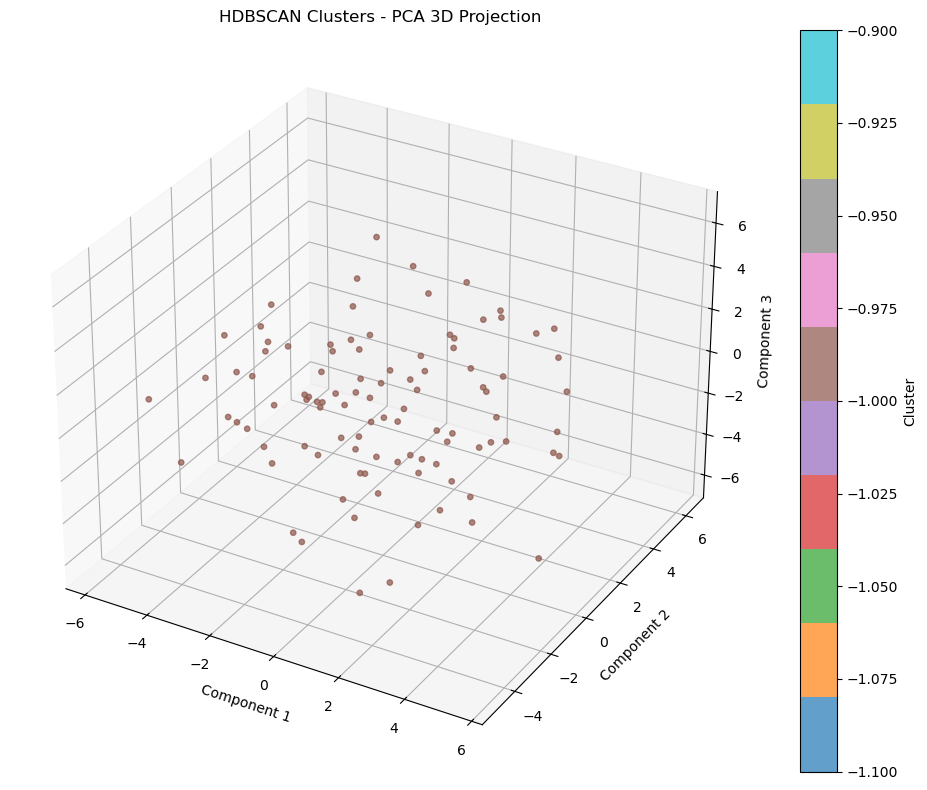

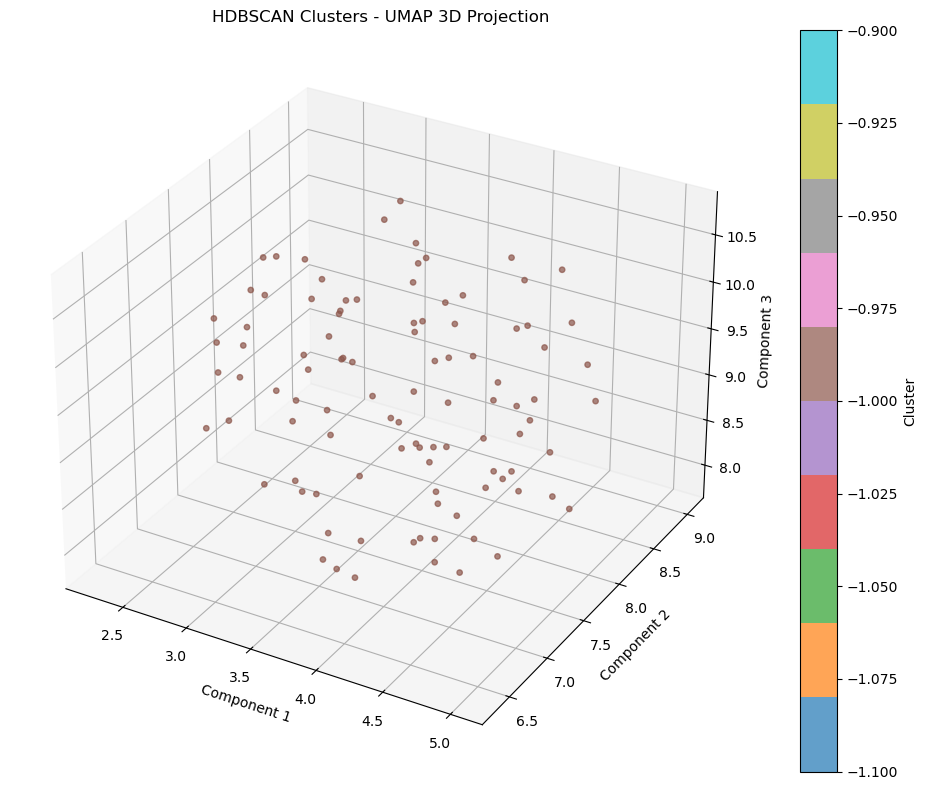


Results saved to 'synthetic_2530_features_clustered.csv'


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import hdbscan
import umap
import time
import seaborn as sns

# ========================= CONFIG =========================
n_samples = 100          # ← Change as needed
n_features = 253
random_state = 42

print(f"Generating dataset: {n_samples:,} samples × {n_features} features\n")
# =========================================================

# 1. Generate random data
np.random.seed(random_state)
X = np.random.randn(n_samples, n_features).astype(np.float32)

# Optional: Create more realistic clusters (uncomment if you prefer)
# from sklearn.datasets import make_blobs
# X, _ = make_blobs(n_samples=n_samples, n_features=n_features, centers=8, 
#                   cluster_std=3.0, random_state=random_state)

# 2. Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data scaled successfully.\n")

# ========================= CLUSTERING =========================

# --- KMeans ---
print("Running KMeans...")
start = time.time()
kmeans = KMeans(n_clusters=8, random_state=random_state, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_time = time.time() - start

# --- HDBSCAN ---
print("Running HDBSCAN...")
start = time.time()
hdb = hdbscan.HDBSCAN(min_cluster_size=50, 
                      min_samples=20,
                      metric='euclidean',
                      cluster_selection_method='eom')
hdb_labels = hdb.fit_predict(X_scaled)
hdb_time = time.time() - start

print(f"KMeans  completed in {kmeans_time:.2f}s")
print(f"HDBSCAN completed in {hdb_time:.2f}s\n")

# ========================= CLUSTER DISTRIBUTION =========================
def print_cluster_distribution(labels, method_name):
    unique, counts = np.unique(labels, return_counts=True)
    dist = pd.DataFrame({'Cluster': unique, 'Count': counts})
    dist['Percentage'] = (dist['Count'] / len(labels) * 100).round(2)
    print(f"\n=== {method_name} Cluster Distribution ===")
    print(dist.sort_values('Cluster'))
    print(f"Total clusters (excluding noise): {len(unique) - (1 if -1 in unique else 0)}")
    if -1 in unique:
        print(f"Noise points: {dist[dist['Cluster'] == -1]['Count'].values[0]}")

print_cluster_distribution(kmeans_labels, "KMeans")
print_cluster_distribution(hdb_labels, "HDBSCAN")

# ========================= DIMENSIONALITY REDUCTION (3D) =========================
print("\nReducing dimensions to 3D for visualization...")

# PCA (Fast and good baseline)
pca = PCA(n_components=3, random_state=random_state)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.2%}")

# UMAP (Better at preserving local structure - slower)
print("Running UMAP...")
umap_reducer = umap.UMAP(n_components=3, random_state=random_state, n_neighbors=30, min_dist=0.1)
X_umap = umap_reducer.fit_transform(X_scaled)

# ========================= 3D VISUALIZATION =========================
def plot_3d(X_3d, labels, title, method='PCA'):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    scatter = ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2],
                         c=labels, cmap='tab10', s=15, alpha=0.7)
    
    ax.set_title(f'{title} - {method} 3D Projection')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.set_zlabel('Component 3')
    
    plt.colorbar(scatter, label='Cluster')
    plt.tight_layout()
    plt.show()

# Plot KMeans clusters
plot_3d(X_pca, kmeans_labels, "KMeans Clusters", "PCA")
plot_3d(X_umap, kmeans_labels, "KMeans Clusters", "UMAP")

# Plot HDBSCAN clusters
plot_3d(X_pca, hdb_labels, "HDBSCAN Clusters", "PCA")
plot_3d(X_umap, hdb_labels, "HDBSCAN Clusters", "UMAP")

# ========================= SAVE RESULTS =========================
df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(n_features)])
df['kmeans_cluster'] = kmeans_labels
df['hdbscan_cluster'] = hdb_labels

df.to_csv('synthetic_2530_features_clustered.csv', index=False)
print("\nResults saved to 'synthetic_2530_features_clustered.csv'")